## 1. Mount Google Drive

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Define Paths

In [19]:
BASE_PATH = "/content/drive/MyDrive/job-posting-classifier"

DATA_PROCESSED = BASE_PATH + "/data/processed/cleaned_data.csv"
SVM_MODEL_PATH = BASE_PATH + "/models/svm_model.pkl"
TFIDF_PATH = BASE_PATH + "/models/tfidf_vectorizer.pkl"
BERT_MODEL_PATH = BASE_PATH + "/models/distilbert_model"
META_MODEL_PATH = BASE_PATH + "/models/meta_model.pkl"

## 3. Install Libraries

In [9]:

!pip install transformers scikit-learn joblib

## 4. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import joblib
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt

## 5. Load Dataset

In [21]:
df = pd.read_csv(DATA_PROCESSED)

print(df.shape)

df.head()

(15886, 2)


,text,formatted_work_type
0,licensed insurance agent while many industries...,Full-time
1,sales manager are you a dynamic and creative m...,Full-time
2,model risk auditor join us as a model risk aud...,Contract
3,business manager business managerfirst baptist...,Full-time
4,ny studio assistant you could be one of the ma...,Full-time


## 6. Train/Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["formatted_work_type"],
    test_size=0.2,
    random_state=42,
    stratify=df["formatted_work_type"]
)

##7. Load SVM Model

In [23]:
svm_model = joblib.load(SVM_MODEL_PATH)
tfidf = joblib.load(TFIDF_PATH)
meta_model = joblib.load(META_MODEL_PATH)

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device)
bert_model.eval()

print("All models loaded successfully")

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

All models loaded successfully


## 8. TF-IDF Vectorizer

In [8]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # tfidf = TfidfVectorizer(
# #     max_features=20000,
# #     ngram_range=(1,3),
# #     stop_words="english"
# # )

# # X_train_tfidf = tfidf.fit_transform(X_train)
# TFIDF_PATH = BASE_PATH + "/models/tfidf_vectorizer.pkl"

# tfidf = joblib.load(TFIDF_PATH)

# print("TF-IDF loaded")
# X_test_tfidf = tfidf.transform(X_test)

## 9. SVM Predictions

In [24]:
X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

svm_train_probs = svm_model.predict_proba(X_train_tfidf)
svm_test_probs = svm_model.predict_proba(X_test_tfidf)

## 10. Load DistilBERT Model

In [10]:
# tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)

# bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)

# device = "cuda" if torch.cuda.is_available() else "cpu"

# bert_model.to(device)

# print("BERT model loaded")

## 11. Label Mapping

In [11]:
# classes = sorted(df["formatted_work_type"].unique())

# class_to_idx = {c:i for i,c in enumerate(classes)}

# idx_to_class = {i:c for c,i in class_to_idx.items()}

## 12. BERT Prediction Function

In [25]:
# bert_model.eval()

# import torch.nn.functional as F

def bert_predict_proba(texts):
    probs = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=192
        ).to(device)

        with torch.no_grad():
            outputs = bert_model(**inputs)

        prob = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        probs.append(prob)

    return np.array(probs)

bert_train_probs = bert_predict_proba(X_train.tolist())
bert_test_probs = bert_predict_proba(X_test.tolist())

# def bert_predict(texts):

#     preds = []

#     for text in texts:

#         inputs = tokenizer(
#             text,
#             return_tensors="pt",
#             truncation=True,
#             padding=True,
#             max_length=96
#         ).to(device)

#         with torch.no_grad():

#             outputs = bert_model(**inputs)

#         pred = torch.argmax(outputs.logits, dim=1).item()

#         preds.append(idx_to_class[pred])

#     return preds

## 13. Get BERT Predictions

In [13]:
# bert_probs = bert_predict_proba(X_test.tolist())
# #bert_preds = bert_predict(X_test.tolist())

## 14. Convert Labels to Numbers

In [14]:
# svm_idx = np.array([class_to_idx[p] for p in svm_preds])

# bert_idx = np.array([class_to_idx[p] for p in bert_preds])

## 15. Ensemble Prediction

In [15]:
# ensemble_idx = []

# for s,b in zip(svm_idx, bert_idx):

#     if s == b:
#         ensemble_idx.append(s)

#     else:
#         ensemble_idx.append(b)  # prefer SVM when conflict

# ensemble_preds = [idx_to_class[i] for i in ensemble_idx]

In [26]:
X_meta_train = np.hstack((bert_train_probs, svm_train_probs))
X_meta_test = np.hstack((bert_test_probs, svm_test_probs))

In [23]:
# X_meta = np.hstack((bert_probs, svm_probs))


### Train Meta Model

In [24]:
# from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(X_meta_train, y_train)

joblib.dump(meta_model, META_MODEL_PATH)
print("Meta model saved")

Meta model saved


### Predict using Meta Model

In [25]:
# ensemble_idx = meta_model.predict(X_meta)
# ensemble_preds = [idx_to_class[i] for i in ensemble_idx]

## Probability Ensemble

In [26]:
# ensemble_probs = 0.95 * bert_probs + 0.05 * svm_probs

## Final Predictions

In [27]:
# ensemble_idx = np.argmax(ensemble_probs, axis=1)

# ensemble_preds = [idx_to_class[i] for i in ensemble_idx]

## 16. Evaluate Ensemble Model

In [27]:
ensemble_preds = meta_model.predict(X_meta_test)

print("Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))

print("\nClassification Report:\n")
print(classification_report(y_test, ensemble_preds))

Ensemble Accuracy: 0.9836375078665828

Classification Report:

              precision    recall  f1-score   support

    Contract       0.98      0.97      0.98       348
   Full-time       0.99      0.99      0.99      2570
  Internship       0.87      0.91      0.89        22
       Other       0.91      0.58      0.71        36
   Part-time       0.95      0.96      0.95       202

    accuracy                           0.98      3178
   macro avg       0.94      0.88      0.90      3178
weighted avg       0.98      0.98      0.98      3178



In [ ]:
# joblib.dump(meta_model, BASE_PATH + "/models/meta_model.pkl")

# print("Meta model saved")

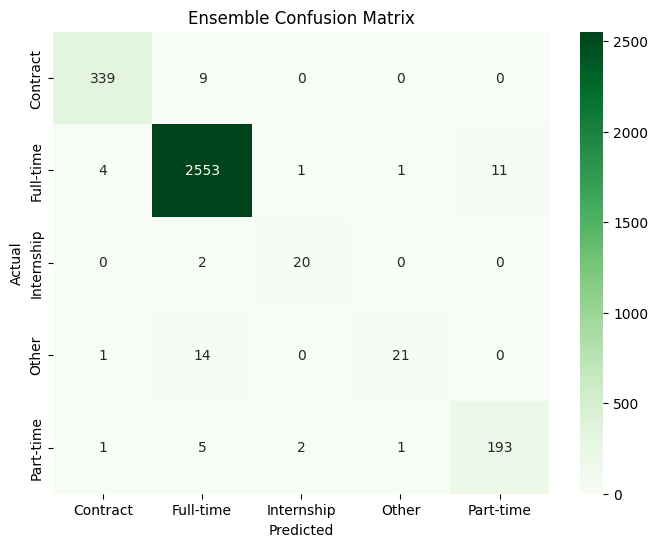

In [28]:
classes = sorted(df["formatted_work_type"].unique())

cm = confusion_matrix(y_test, ensemble_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Ensemble Confusion Matrix")

plt.show()

In [ ]:
# import joblib

# ENSEMBLE_PATH = BASE_PATH + "/models/ensemble_model.pkl"

# ensemble_bundle = {
#     "svm_model": svm_model,
#     "tfidf_vectorizer": tfidf,
#     "bert_model_path": BERT_MODEL_PATH,
#     "class_to_idx": class_to_idx,
#     "idx_to_class": idx_to_class
# }

# joblib.dump(ensemble_bundle, ENSEMBLE_PATH)

# print("Ensemble model saved at:", ENSEMBLE_PATH)

In [29]:
def ensemble_predict(text):

    # SVM
    text_tfidf = tfidf.transform([text])
    svm_prob = svm_model.predict_proba(text_tfidf)

    # BERT
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=192
    ).to(device)

    with torch.no_grad():
        outputs = bert_model(**inputs)

    bert_prob = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    # Combine
    meta_input = np.hstack((bert_prob, svm_prob))

    pred = meta_model.predict(meta_input)

    return pred[0]

In [30]:
text = "Looking for a part-time retail sales associate with weekend availability"

prediction = ensemble_predict(text)

print("Predicted Job Type:", prediction)

Predicted Job Type: Part-time
